## Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

In [3]:
# Reproducibility
np.random.seed(42)

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

## Step 2: Load the Dataset

In [5]:
# Load CSVs
ratings = pd.read_csv("ratings.csv")
movies  = pd.read_csv("movies.csv")

print(f"\nRatings shape : {ratings.shape}")
print(f"Movies  shape : {movies.shape}")
display(ratings.head())
display(movies.head())


Ratings shape : (100836, 4)
Movies  shape : (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


#### Dataset Overview
The ratings dataset contains 100,836 ratings across 4 columns: userId, movieId, rating, and timestamp. The movies dataset contains 9,742 movies with their titles and genre labels.
From the preview, ratings are stored as floats (e.g. 4.0, 5.0) on a scale from 0.5 to 5.0 in 0.5 increments. Each row in ratings.csv represents a single user-movie interaction.

## Step 3: Exploratory Data Analysis (EDA)

Before building the model we inspect the data to understand its structure, density, and potential biases. Key questions:
- How are ratings distributed?
- How many ratings does a typical user or movie have?
- How sparse is the utility matrix?

Understanding sparsity is critical: in a very sparse matrix most similarity scores will be computed from very few co-rated items, reducing reliability.


In [6]:
# Basic statistics
n_users  = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)

print("=" * 50)
print(f"  Unique users         : {n_users:,}")
print(f"  Unique movies rated  : {n_movies:,}")
print(f"  Total ratings        : {n_ratings:,}")
print(f"  Rating scale         : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"  Matrix sparsity      : {sparsity:.2%}")
print("=" * 50)

  Unique users         : 610
  Unique movies rated  : 9,724
  Total ratings        : 100,836
  Rating scale         : 0.5 – 5.0
  Matrix sparsity      : 98.30%


The dataset contains 610 unique users who have collectively rated 9,724 movies, producing 100,836 ratings in total. Ratings follow a 0.5–5.0 scale in 0.5 increments. The utility matrix has a sparsity of 98.30%, meaning only about 1 in 58 possible user–movie pairs has a rating, this is typical for recommender systems but highlights why similarity computations must be handled carefully, as most movies share very few co-raters.

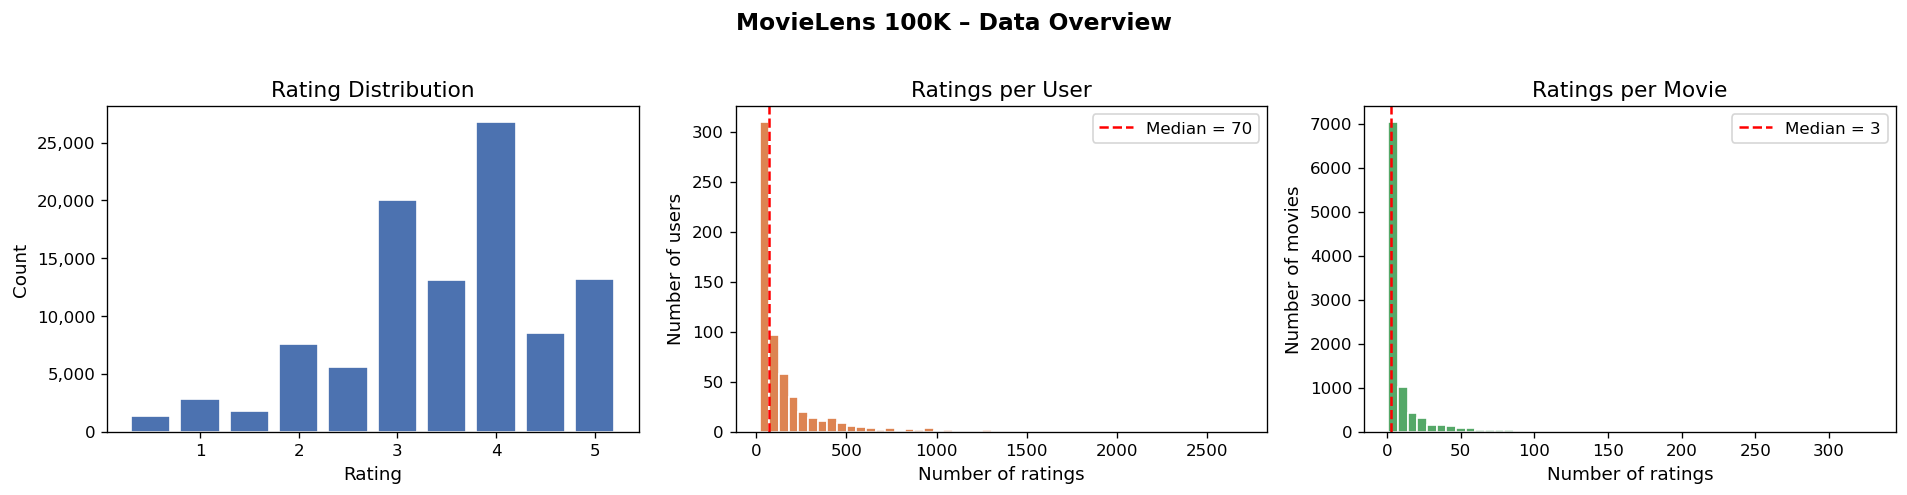

Figure saved ✓


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1 – Rating distribution
ax = axes[0]
rating_counts = ratings["rating"].value_counts().sort_index()
ax.bar(rating_counts.index, rating_counts.values, width=0.4, color="#4C72B0", edgecolor="white")
ax.set_title("Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 2 – Ratings per user
ax = axes[1]
user_counts = ratings.groupby("userId").size()
ax.hist(user_counts, bins=50, color="#DD8452", edgecolor="white")
ax.set_title("Ratings per User")
ax.set_xlabel("Number of ratings")
ax.set_ylabel("Number of users")
ax.axvline(user_counts.median(), color="red", linestyle="--", label=f"Median = {user_counts.median():.0f}")
ax.legend()

# 3 – Ratings per movie
ax = axes[2]
movie_counts = ratings.groupby("movieId").size()
ax.hist(movie_counts, bins=50, color="#55A868", edgecolor="white")
ax.set_title("Ratings per Movie")
ax.set_xlabel("Number of ratings")
ax.set_ylabel("Number of movies")
ax.axvline(movie_counts.median(), color="red", linestyle="--", label=f"Median = {movie_counts.median():.0f}")
ax.legend()

plt.suptitle("MovieLens 100K – Data Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight")
plt.show()

#### Rating Distribution: 
The distribution is left-skewed, with the majority of ratings falling between 3.0 and 4.0. Rating 4.0 is the single most common value (~26,000 ratings), and whole-number ratings (1, 2, 3, 4, 5) are given far more frequently than half-star ratings. This suggests users tend to round their ratings and generally rate movies positively — likely because people are more inclined to rate films they chose to watch and enjoyed.

#### Ratings per User: 
Highly right-skewed with a median of just 70 ratings. Most users have rated fewer than 200 movies, but a small number of power users have rated over 1,000. This imbalance means recommendations will be much more reliable for active users than casual ones.

#### Ratings per Movie: 
Also heavily right-skewed with a median of only 3 ratings. The vast majority of movies have been rated by very few users, which is precisely why we apply a minimum-rating filter before building the utility matrix.

## Step 4: Build the Utility Matrix

The utility matrix (also called the user-item matrix) is the foundation of collaborative filtering.
- Rows → users  
- Columns → movies  
- Entries → explicit rating (0.5-5.0), or `NaN` where no rating exists

#### Filtering for quality
We apply a minimum-count filter to reduce noise:
- Keep only movies rated by at least 10 users (ensures enough co-rating overlap for meaningful similarity)
- Keep only users who rated at least 10 movies (avoids cold-start users who contribute little signal)

This is a common pre-processing step in production CF pipelines.

In [41]:
MIN_MOVIE_RATINGS = 10
MIN_USER_RATINGS  = 10

# Filter movies
movie_rating_counts = ratings.groupby("movieId").size()
qualified_movies = movie_rating_counts[movie_rating_counts >= MIN_MOVIE_RATINGS].index

# Filter users
user_rating_counts = ratings.groupby("userId").size()
qualified_users = user_rating_counts[user_rating_counts >= MIN_USER_RATINGS].index

filtered = ratings[
    ratings["movieId"].isin(qualified_movies) &
    ratings["userId"].isin(qualified_users)
]

print("After filtering:")
print(f"  Users           : {filtered['userId'].nunique():,}")
print(f"  Movies          : {filtered['movieId'].nunique():,}")
print(f"  Ratings         : {len(filtered):,}")

# Build utility matrix
utility_matrix = filtered.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

sparsity_filtered = 1 - utility_matrix.notna().sum().sum() / utility_matrix.size

print(f"  Matrix shape    : {utility_matrix.shape}")
print(f"  Sparsity        : {sparsity_filtered:.2%}")

# Display random users and movies
sample_users = utility_matrix.sample(5, random_state=42)
sample_display = sample_users.sample(8, axis=1, random_state=42)

display(sample_display)

After filtering:
  Users           : 610
  Movies          : 2,269
  Ratings         : 81,116
  Matrix shape    : (610, 2269)
  Sparsity        : 94.14%


movieId,372,4023,6709,5673,1717,1277,2423,5013
userId,,,,,,,,
82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
599,NaN,NaN,2.0,3.5,NaN,NaN,3.0,3.0
265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The utility matrix remains highly sparse even after filtering, with a sparsity of 94.14%. This indicates that users rate only a small subset of available movies. Such sparsity makes recommendation difficult because many movie pairs have few or no common ratings. Filtering movies with very few ratings helps improve the reliability of similarity calculations used in item-based collaborative filtering.

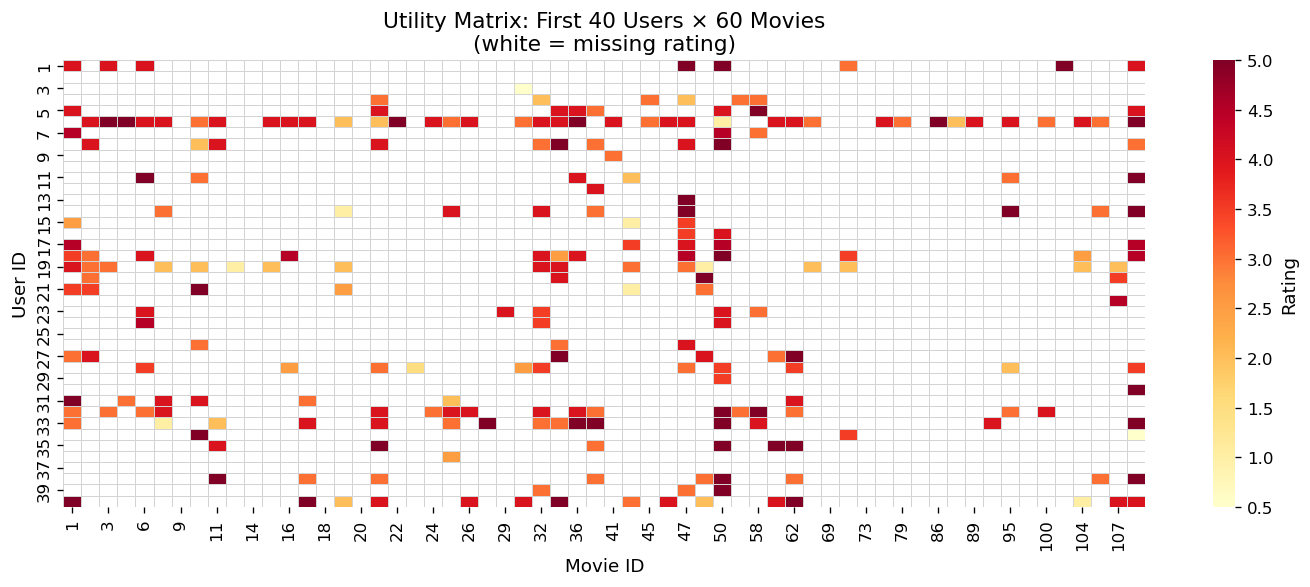

In [42]:
# Visualise a submatrix heatmap
fig, ax = plt.subplots(figsize=(12, 5))
subset = utility_matrix.iloc[:40, :60]
mask   = subset.isna()

sns.heatmap(
    subset,
    mask=mask,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="lightgrey",
    cbar_kws={"label": "Rating"},
    ax=ax,
    vmin=0.5, vmax=5.0,
)
ax.set_title("Utility Matrix: First 40 Users × 60 Movies\n(white = missing rating)", fontsize=13)
ax.set_xlabel("Movie ID")
ax.set_ylabel("User ID")
plt.tight_layout()
plt.savefig("utility_matrix_heatmap.png", bbox_inches="tight")
plt.show()

## Step 5: Similarity Measures

For item-based CF we need to quantify *how similar two movies are* based on the ratings they received. We implement and compare two classic measures.

#### 5.1 Cosine Similarity
- Strengths: Fast, works well when magnitude differences are meaningful.  
- Weakness: Does not account for individual user rating biases (e.g. a user who always rates 4-5 versus one who rates 1-3).


#### 5.2 Pearson Correlation Similarity
- Key difference: Uses only co-rated users and subtracts each movie's mean, making it bias-corrected. This is generally more accurate for rating-scale data.

We will compute both and inspect how their results differ.


In [43]:
# 5.1 Cosine Similarity
# Fill NaN with 0 (unrated = neutral) for cosine computation
item_matrix = utility_matrix.T.fillna(0)   # shape: movies × users

cosine_sim_matrix = cosine_similarity(item_matrix)
cosine_sim_df = pd.DataFrame(
    cosine_sim_matrix,
    index=utility_matrix.columns,
    columns=utility_matrix.columns,
)

print(f"Cosine similarity matrix shape: {cosine_sim_df.shape}")
print(f"Value range: [{cosine_sim_matrix.min():.4f}, {cosine_sim_matrix.max():.4f}]")
display(cosine_sim_df.iloc[:5, :5])


Cosine similarity matrix shape: (2269, 2269)
Value range: [0.0000, 1.0000]


movieId,1,2,3,5,6
movieId,,,,,
1,1.000000,0.410562,0.296917,0.308762,0.376316
2,0.410562,1.000000,0.282438,0.287795,0.297009
3,0.296917,0.282438,1.000000,0.417802,0.284257
5,0.308762,0.287795,0.417802,1.000000,0.298969
6,0.376316,0.297009,0.284257,0.298969,1.000000


In [44]:
# 5.2 Pearson Correlation Similarity
# pandas .corr() computes pairwise Pearson on columns, handling NaN correctly
# (only uses co-rated entries)
pearson_sim_df = utility_matrix.corr(method="pearson", min_periods=5)

print(f"Pearson similarity matrix shape: {pearson_sim_df.shape}")
print(f"NaN entries: {pearson_sim_df.isna().sum().sum():,}  (pairs with < 5 co-ratings)")
display(pearson_sim_df.iloc[:5, :5])

Pearson similarity matrix shape: (2269, 2269)
NaN entries: 2,880,308  (pairs with < 5 co-ratings)


movieId,1,2,3,5,6
movieId,,,,,
1,1.000000,0.330978,0.487109,0.310971,0.106465
2,0.330978,1.000000,0.419564,0.562791,0.163510
3,0.487109,0.419564,1.000000,0.602266,0.345069
5,0.310971,0.562791,0.602266,1.000000,0.291302
6,0.106465,0.163510,0.345069,0.291302,1.000000


Cosine similarity produced a complete similarity matrix because missing ratings were replaced with zeros before computation. Pearson correlation, however, only uses users who rated both movies. Due to the high sparsity of the utility matrix, many movie pairs did not have the minimum five co-ratings required, resulting in a large number of NaN similarity values.

## Step 6: Visualising the Similarity Matrices

We visualise a 50 × 50 sub-matrix for each measure to compare their structure.

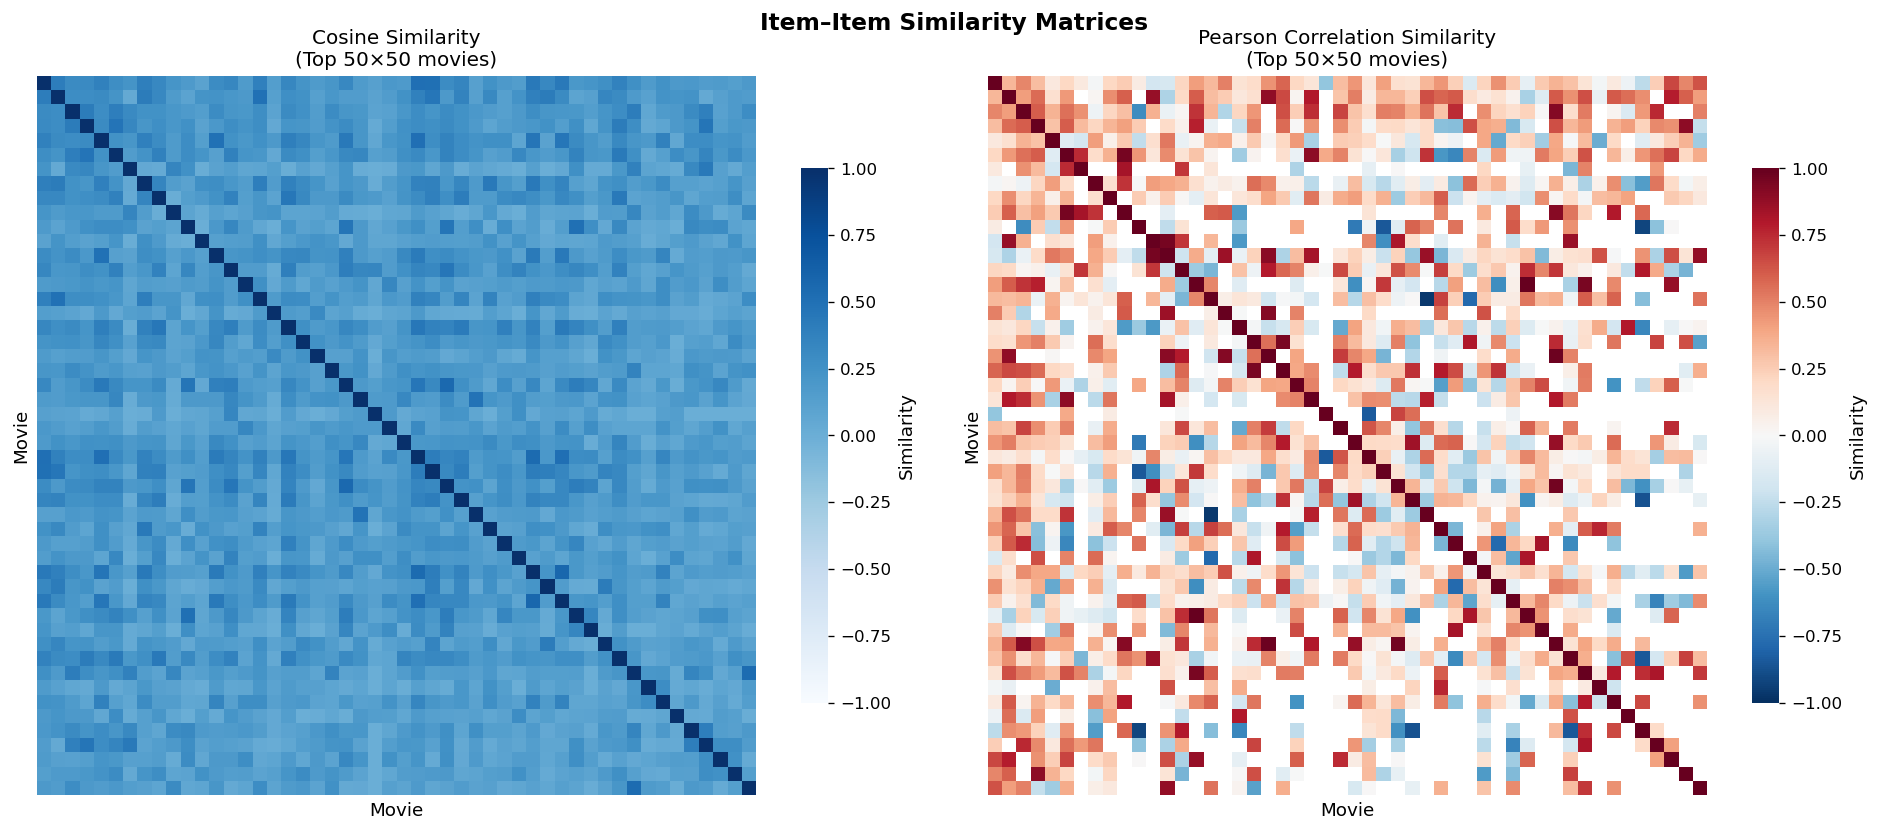

In [45]:
N = 50  # sub-matrix size for visualisation

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, sim_df, title, cmap in zip(
    axes,
    [cosine_sim_df, pearson_sim_df],
    ["Cosine Similarity", "Pearson Correlation Similarity"],
    ["Blues", "RdBu_r"],
):
    sub = sim_df.iloc[:N, :N]
    mask = sub.isna()
    sns.heatmap(
        sub,
        mask=mask,
        cmap=cmap,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0,
        cbar_kws={"shrink": 0.7, "label": "Similarity"},
        ax=ax,
        xticklabels=False,
        yticklabels=False,
    )
    ax.set_title(f"{title}\n(Top {N}×{N} movies)", fontsize=12)
    ax.set_xlabel("Movie")
    ax.set_ylabel("Movie")

plt.suptitle("Item–Item Similarity Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("similarity_matrices.png", bbox_inches="tight")
plt.show()


Most movie pairs have weak to moderate positive similarity, with only a few highly similar pairs. The matrix appears relatively smooth because cosine similarity was computed for every movie pair after replacing missing ratings with zeros.

Pearson correlation produces a more varied similarity structure, including both positive and negative relationships. Because it relies only on co-rated movies, many movie pairs have insufficient overlap, resulting in missing values and a less uniform heatmap.

## Step 7: Recommendation Engine

#### How Item-Based CF Makes Recommendations
We implement three functions:
1. `get_similar_movies`: find the top-K most similar movies to a given movie  
2. `predict_rating`: estimate what a user would rate an unseen movie  
3. `recommend_for_user`: produce a ranked list of recommended movies for a user

In [47]:
# Helper: map movieId ↔ title
id_to_title = dict(zip(movies["movieId"], movies["title"]))
title_to_id = dict(zip(movies["title"], movies["movieId"]))

# Count how many users rated each pair of movies
co_ratings = (
    utility_matrix.notna()
    .astype(int)
    .T
    .dot(utility_matrix.notna().astype(int))
)

def get_similar_movies(movie_id, sim_df, top_n=10, min_overlap=20):
    """Return the top-N most similar movies to movie_id."""

    if movie_id not in sim_df.index:
        raise ValueError(f"movieId {movie_id} not in similarity matrix.")

    scores = sim_df[movie_id].drop(index=movie_id).dropna()

    # Keep only movie pairs with enough common ratings
    overlaps = co_ratings.loc[movie_id]
    scores = scores[overlaps >= min_overlap]

    top = scores.sort_values(ascending=False).head(top_n).reset_index()

    top.columns = ["movieId", "similarity"]
    top["title"] = top["movieId"].map(id_to_title)

    return top[["movieId", "title", "similarity"]]

def predict_rating(user_id, movie_id, utility_matrix, sim_df, top_k=20):
    """
    Predict the rating of `user_id` for `movie_id` using weighted average
    of the user's ratings for the top-K most similar movies.
    """
    if movie_id not in sim_df.columns:
        return np.nan

    # Movies rated by this user
    user_ratings = utility_matrix.loc[user_id].dropna()

    # Similarity between target movie and all movies rated by user
    sim_scores = sim_df[movie_id].reindex(user_ratings.index).dropna()
    sim_scores = sim_scores[sim_scores > 0].nlargest(top_k)

    if sim_scores.empty:
        return np.nan

    numerator   = (sim_scores * user_ratings.reindex(sim_scores.index)).sum()
    denominator = sim_scores.abs().sum()

    return numerator / denominator if denominator != 0 else np.nan


def recommend_for_user(user_id, utility_matrix, sim_df, top_n=10, top_k=20):
    """
    Produce top-N movie recommendations for a user.
    Only considers movies the user has NOT yet rated.
    """
    if user_id not in utility_matrix.index:
        raise ValueError(f"userId {user_id} not in utility matrix.")

    rated_movies   = utility_matrix.loc[user_id].dropna().index
    unrated_movies = [m for m in utility_matrix.columns if m not in rated_movies]

    predictions = {}
    for movie_id in unrated_movies:
        pred = predict_rating(user_id, movie_id, utility_matrix, sim_df, top_k)
        if not np.isnan(pred):
            predictions[movie_id] = pred

    recs = (pd.Series(predictions)
              .sort_values(ascending=False)
              .head(top_n)
              .reset_index())
    recs.columns = ["movieId", "predicted_rating"]
    recs["title"] = recs["movieId"].map(id_to_title)
    return recs[["movieId", "title", "predicted_rating"]]


print("Recommendation functions defined ✓")

Recommendation functions defined ✓


#### Recommendation Functions

After computing the item-item similarity matrices, the next step is to generate movie recommendations. To achieve this, several helper functions are defined. First, dictionaries are created to map movie IDs to movie titles and vice versa, making the recommendation results easier to interpret. The get_similar_movies() function retrieves the most similar movies to a given movie based on the chosen similarity matrix. It ranks movies according to their similarity scores and returns the top matches. The predict_rating() function estimates how a user might rate a movie they have not yet watched. The prediction is calculated as a weighted average of the user's ratings for similar movies, where the weights are the similarity scores. This follows the standard item-based collaborative filtering approach, where movies that are more similar have a greater influence on the predicted rating.

Finally, the recommend_for_user() function generates personalized recommendations for a user. It identifies movies the user has not rated, predicts ratings for those movies, and returns the highest-ranked recommendations. This allows the recommender system to suggest movies that are likely to match the user's preferences based on their previous ratings and the similarity relationships between movies.

Together, these functions form the core recommendation engine used to produce personalized movie recommendations from the utility matrix and similarity matrices.

In [39]:
cos_similar = get_similar_movies(1, cosine_sim_df, top_n=10)
display(cos_similar)

pea_similar = get_similar_movies(1, pearson_sim_df, top_n=10)
display(pea_similar)

,movieId,title,similarity
0,3114,Toy Story 2 (1999),0.572601
1,480,Jurassic Park (1993),0.565637
2,780,Independence Day (a.k.a. ID4) (1996),0.564262
3,260,Star Wars: Episode IV - A New Hope (1977),0.557388
4,356,Forrest Gump (1994),0.547096
5,364,"Lion King, The (1994)",0.541145
6,1210,Star Wars: Episode VI - Return of the Jedi (1983),0.541089
7,648,Mission: Impossible (1996),0.538913
8,1265,Groundhog Day (1993),0.534169
9,1270,Back to the Future (1985),0.530381


,movieId,title,similarity
0,3114,Toy Story 2 (1999),0.699211
1,102125,Iron Man 3 (2013),0.674658
2,95167,Brave (2012),0.663129
3,2699,Arachnophobia (1990),0.652424
4,8961,"Incredibles, The (2004)",0.643301
5,6377,Finding Nemo (2003),0.618701
6,588,Aladdin (1992),0.611892
7,3967,Billy Elliot (2000),0.610921
8,3868,"Naked Gun: From the Files of Police Squad!, Th...",0.607630
9,3408,Erin Brockovich (2000),0.598016


## Step 8: Trial: Finding Similar Movies

We pick three popular movies and retrieve their top-10 neighbours under both similarity measures. This lets us do a qualitative sanity-check: do the neighbours make intuitive sense (same genre, era, franchise)?

In [48]:
# Identify popular movies present in the filtered matrix
popular = (filtered.groupby("movieId").size()
           .reindex(utility_matrix.columns)
           .dropna()
           .sort_values(ascending=False))

# Pick three well-known movies
demo_ids = popular.head(15).index.tolist()

# Show their titles
demo_titles = [(mid, id_to_title.get(mid, "Unknown")) for mid in demo_ids[:5]]
print("Most-rated movies in filtered dataset:")
for mid, title in demo_titles:
    print(f"  movieId={mid:6d}  {title}")

Most-rated movies in filtered dataset:
  movieId=   356  Forrest Gump (1994)
  movieId=   318  Shawshank Redemption, The (1994)
  movieId=   296  Pulp Fiction (1994)
  movieId=   593  Silence of the Lambs, The (1991)
  movieId=  2571  Matrix, The (1999)


Before exploring movie similarities, the movies with the highest number of ratings were identified. Movies that receive many ratings generally provide more reliable similarity estimates because they contain information from a larger number of users.

In this step, the filtered ratings data was grouped by movie ID and the number of ratings for each movie was counted. The movies were then sorted in descending order based on their rating counts. The most frequently rated movies were selected as candidate movies for demonstrating the recommender system.

The results show that some of the most-rated movies in the dataset include Forrest Gump (1994), The Shawshank Redemption (1994), Pulp Fiction (1994), The Silence of the Lambs (1991), and The Matrix (1999). These popular movies have substantial user interaction data, making them suitable examples for similarity analysis and recommendation generation.

In [50]:
# Toy Story neighbours
target_id = 1  # Toy Story

if target_id in cosine_sim_df.index:

    print(f"\n{'='*60}")
    print(f"Movies similar to: {id_to_title.get(target_id)}")
    print(f"{'='*60}")

    print("\nTop 10 Similar Movies (Cosine Similarity)")
    print("-" * 60)
    cos_similar = get_similar_movies(
        target_id,
        cosine_sim_df,
        top_n=10
    )
    display(cos_similar.round(4))

    print("\nTop 10 Similar Movies (Pearson Correlation)")
    print("-" * 60)
    pea_similar = get_similar_movies(
        target_id,
        pearson_sim_df,
        top_n=10
    )
    display(pea_similar.round(4))

else:

    target_id = demo_ids[0]

    print(f"\nUsing fallback movie: {id_to_title.get(target_id)}")

    print("\nTop 10 Similar Movies (Cosine Similarity)")
    display(
        get_similar_movies(
            target_id,
            cosine_sim_df,
            top_n=10
        ).round(4)
    )

    print("\nTop 10 Similar Movies (Pearson Correlation)")
    display(
        get_similar_movies(
            target_id,
            pearson_sim_df,
            top_n=10
        ).round(4)
    )


Movies similar to: Toy Story (1995)

Top 10 Similar Movies (Cosine Similarity)
------------------------------------------------------------


,movieId,title,similarity
0,3114,Toy Story 2 (1999),0.5726
1,480,Jurassic Park (1993),0.5656
2,780,Independence Day (a.k.a. ID4) (1996),0.5643
3,260,Star Wars: Episode IV - A New Hope (1977),0.5574
4,356,Forrest Gump (1994),0.5471
5,364,"Lion King, The (1994)",0.5411
6,1210,Star Wars: Episode VI - Return of the Jedi (1983),0.5411
7,648,Mission: Impossible (1996),0.5389
8,1265,Groundhog Day (1993),0.5342
9,1270,Back to the Future (1985),0.5304



Top 10 Similar Movies (Pearson Correlation)
------------------------------------------------------------


,movieId,title,similarity
0,3114,Toy Story 2 (1999),0.6992
1,102125,Iron Man 3 (2013),0.6747
2,95167,Brave (2012),0.6631
3,2699,Arachnophobia (1990),0.6524
4,8961,"Incredibles, The (2004)",0.6433
5,6377,Finding Nemo (2003),0.6187
6,588,Aladdin (1992),0.6119
7,3967,Billy Elliot (2000),0.6109
8,3868,"Naked Gun: From the Files of Police Squad!, Th...",0.6076
9,3408,Erin Brockovich (2000),0.5980


To evaluate the similarity matrices, Toy Story (1995) was selected as a target movie. The get_similar_movies() function was used to retrieve the ten most similar movies according to both cosine similarity and Pearson correlation.

The cosine similarity results primarily identified highly popular movies such as Toy Story 2, Jurassic Park, Star Wars, Forrest Gump, and The Lion King. These movies are frequently co-rated by users, which contributes to their high similarity scores.

The Pearson correlation results produced a different set of neighbours, including Toy Story 2, Brave, The Incredibles, Finding Nemo, and Aladdin. These movies share similar rating patterns among users, suggesting that Pearson correlation captures preference relationships beyond simple co-occurrence.

A notable observation is that Toy Story 2 (1999) appears as the most similar movie under both similarity measures. This is expected because it is a direct sequel to Toy Story and is likely to be enjoyed by many of the same users. The differences between the two lists demonstrate that the choice of similarity measure can significantly influence the neighbours identified for a movie and, consequently, the recommendations generated by the recommender system.

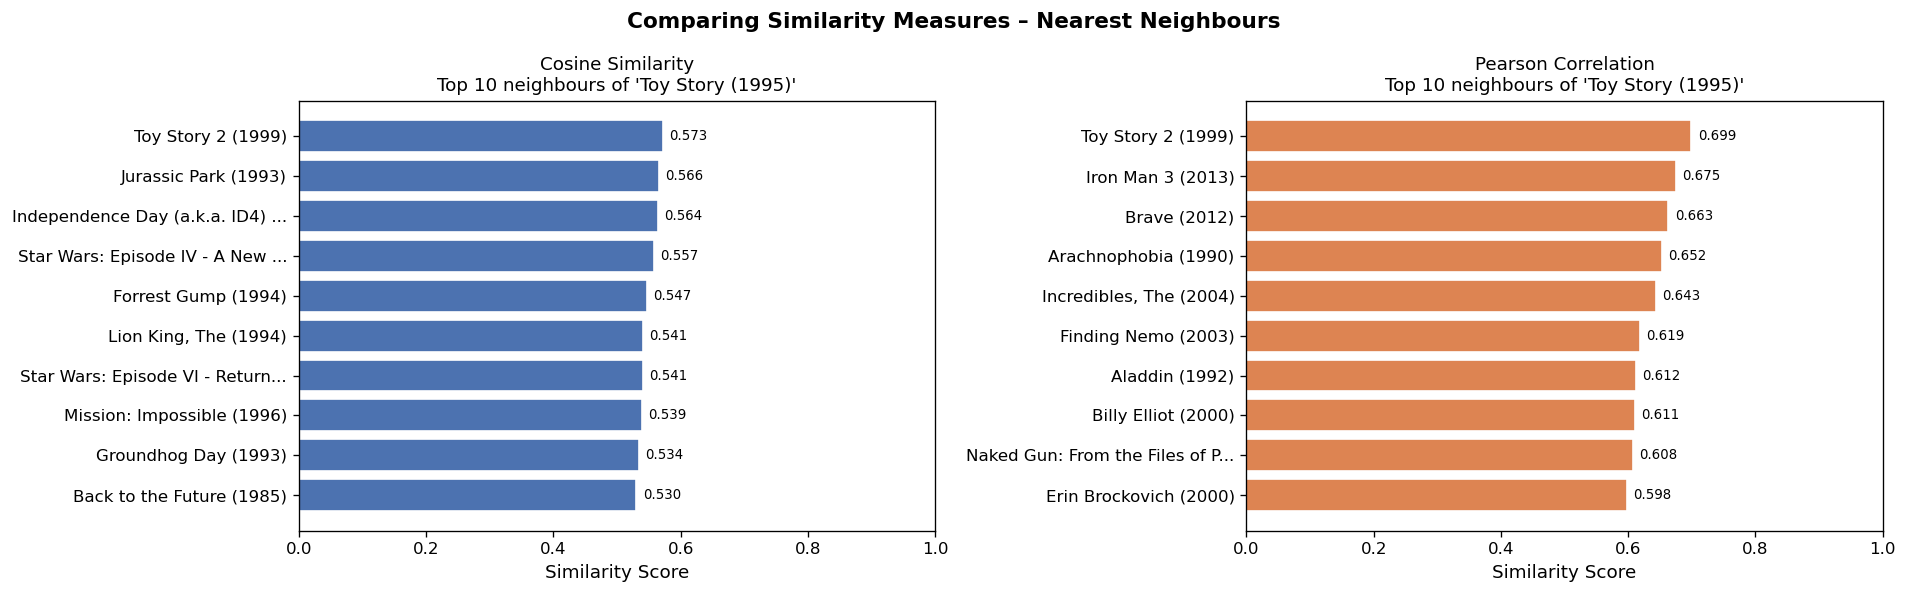

In [52]:
# Visualise similarity scores side-by-side for a chosen movie

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, sim_df, label, colour in zip(
    axes,
    [cosine_sim_df, pearson_sim_df],
    ["Cosine Similarity", "Pearson Correlation"],
    ["#4C72B0", "#DD8452"],
):

    top = get_similar_movies(target_id, sim_df, top_n=10)

    short_titles = [
        t[:30] + "..." if len(t) > 30 else t
        for t in top["title"]
    ]

    ax.barh(
        short_titles[::-1],
        top["similarity"].values[::-1],
        color=colour,
        edgecolor="white"
    )

    ax.set_title(
        f"{label}\nTop 10 neighbours of '{id_to_title.get(target_id, target_id)[:35]}'",
        fontsize=11
    )

    ax.set_xlabel("Similarity Score")
    ax.set_xlim(0, 1)

    for i, v in enumerate(top["similarity"].values[::-1]):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)

plt.suptitle(
    "Comparing Similarity Measures – Nearest Neighbours",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

The bar charts compare the ten nearest neighbours of Toy Story (1995) identified using cosine similarity and Pearson correlation. Although both methods identify Toy Story 2 (1999) as the most similar movie, the remaining recommendations differ considerably.

Cosine similarity primarily recommends widely popular movies such as Jurassic Park, Star Wars, Forrest Gump, and The Lion King. These recommendations arise because cosine similarity measures the overall similarity of rating vectors and tends to favour movies that are frequently co-rated by the same users.

Pearson correlation, on the other hand, recommends movies such as Brave, The Incredibles, Finding Nemo, and Aladdin. These recommendations suggest that Pearson correlation is capturing similarities in rating patterns rather than simply co-occurrence. As a result, the recommendations appear more focused on family-friendly and animated films that share a similar audience with Toy Story.

The figure demonstrates that different similarity measures can produce noticeably different neighbourhoods for the same movie. While cosine similarity tends to highlight broadly popular movies, Pearson correlation may reveal movies that are more closely aligned with users' preferences. This difference can have a significant impact on the recommendations generated by an item-based collaborative filtering system.

## Step 9: Demo: Personalised Recommendations

We generate Top-10 recommendations for a sample user and compare the outputs from both similarity measures.

The predicted rating reflects a *weighted average* of ratings the user gave to movies that are similar to the candidate movie. A higher predicted rating means the candidate is both **similar** to movies the user loved **and** those ratings pull the weighted average up.


In [53]:
# Pick a user who rated many movies (reliable history)
power_user = (filtered.groupby("userId").size()
              .reindex(utility_matrix.index)
              .dropna()
              .idxmax())

print(f"Demonstration user: userId = {power_user}")
print(f"Total ratings given: {int(filtered[filtered['userId']==power_user].shape[0])}")

# Show their top-rated movies as context
user_history = (filtered[filtered["userId"] == power_user]
                .merge(movies, on="movieId")
                .sort_values("rating", ascending=False)
                .head(10)[["title", "rating"]])

print("\nUser's top-rated movies:")
display(user_history)

Demonstration user: userId = 414
Total ratings given: 1634

User's top-rated movies:


,title,rating
662,Heartbreak Ridge (1986),5.0
369,"Graduate, The (1967)",5.0
1111,Secretary (2002),5.0
379,Unforgiven (1992),5.0
1112,Spirited Away (Sen to Chihiro no kamikakushi) ...,5.0
1116,Strange Brew (1983),5.0
376,"Great Escape, The (1963)",5.0
374,Stand by Me (1986),5.0
373,Better Off Dead... (1985),5.0
372,Chinatown (1974),5.0


The cosine similarity recommender produced recommendations dominated by highly acclaimed classic films, including Psycho, 12 Angry Men, The Shining, The Third Man, and Life Is Beautiful. These movies are frequently co-rated by users who enjoy classic cinema and highly rated dramas.

The recommendations appear consistent with the user's existing preferences, which include films such as Chinatown, The Graduate, and Unforgiven. Cosine similarity tends to favour movies that are frequently liked by similar groups of users, resulting in recommendations that are broadly popular among users with comparable viewing histories.

In [56]:
print("Generating recommendations … (this may take ~30 s)")

cosine_recs  = recommend_for_user(power_user, utility_matrix, cosine_sim_df,  top_n=10)
pearson_recs = recommend_for_user(power_user, utility_matrix, pearson_sim_df, top_n=10)

print("\n" + "="*55)
print(f"  Top-10 Recommendations (Cosine)  –  userId {power_user}")
print("="*55)
display(cosine_recs.round(3))

print("\n" + "="*55)
print(f"  Top-10 Recommendations (Pearson) –  userId {power_user}")
print("="*55)
display(pearson_recs.round(3))

Generating recommendations … (this may take ~30 s)

  Top-10 Recommendations (Cosine)  –  userId 414


,movieId,title,predicted_rating
0,1219,Psycho (1960),4.903
1,1203,12 Angry Men (1957),4.771
2,3681,For a Few Dollars More (Per qualche dollaro in...,4.729
3,1258,"Shining, The (1980)",4.654
4,1245,Miller's Crossing (1990),4.607
5,1212,"Third Man, The (1949)",4.590
6,2324,Life Is Beautiful (La Vita è bella) (1997),4.528
7,3462,Modern Times (1936),4.517
8,1237,"Seventh Seal, The (Sjunde inseglet, Det) (1957)",4.500
9,8228,"Maltese Falcon, The (a.k.a. Dangerous Female) ...",4.478



  Top-10 Recommendations (Pearson) –  userId 414


,movieId,title,predicted_rating
0,1289,Koyaanisqatsi (a.k.a. Koyaanisqatsi: Life Out ...,4.692
1,55442,Persepolis (2007),4.682
2,1927,All Quiet on the Western Front (1930),4.680
3,1131,Jean de Florette (1986),4.653
4,116897,Wild Tales (2014),4.644
5,2731,"400 Blows, The (Les quatre cents coups) (1959)",4.640
6,1537,Shall We Dance? (Shall We Dansu?) (1996),4.625
7,3742,Battleship Potemkin (1925),4.600
8,3067,Women on the Verge of a Nervous Breakdown (Muj...,4.580
9,1483,Crash (1996),4.571


The Pearson correlation recommender generated a different set of recommendations, including Persepolis, All Quiet on the Western Front, Jean de Florette, The 400 Blows, and Battleship Potemkin. Compared to cosine similarity, these recommendations are more focused on international cinema, classic films, and critically acclaimed works.

Pearson correlation measures similarity based on rating patterns rather than overall popularity. As a result, it often identifies movies that appeal to users with similar tastes, even when those movies are not among the most frequently rated titles.

In [57]:
# Overlap analysis
cosine_set  = set(cosine_recs["movieId"])
pearson_set = set(pearson_recs["movieId"])
overlap     = cosine_set & pearson_set

print(f"\nOverlap between Cosine and Pearson top-10: {len(overlap)} movies")
if overlap:
    overlap_titles = [id_to_title.get(m, m) for m in overlap]
    for t in overlap_titles:
        print(f"  • {t}")


Overlap between Cosine and Pearson top-10: 0 movies


An interesting observation is that there was no overlap between the top ten recommendations generated by cosine similarity and Pearson correlation. This demonstrates that different similarity measures can produce substantially different recommendation lists.

Cosine similarity tended to recommend widely recognized classic films that are frequently co-rated by users with similar interests. In contrast, Pearson correlation emphasized movies with similar rating patterns, leading to recommendations that were more specialized and focused on particular viewing preferences.

This result highlights the importance of the similarity measure chosen in an item-based collaborative filtering system, as different measures can lead to different recommendation outcomes.

## Step 10: Model Evaluation

To quantify prediction accuracy we use a Leave-One-Out (LOO) evaluation on a random sample of 200 user–movie pairs:

1. For each sampled (user, movie) pair with a known rating, we hide the rating.
2. We predict the rating using the remaining data.
3. We compute Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE):

Lower values indicate better prediction accuracy.

In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

SAMPLE_SIZE = 200
np.random.seed(42)

# Sample known ratings from the filtered set
known = filtered[["userId", "movieId", "rating"]].sample(SAMPLE_SIZE)

def evaluate(known_df, utility_matrix, sim_df, label, top_k=20):
    actuals, preds = [], []
    for _, row in known_df.iterrows():
        uid, mid, actual = int(row["userId"]), int(row["movieId"]), row["rating"]
        if uid not in utility_matrix.index or mid not in sim_df.columns:
            continue
        pred = predict_rating(uid, mid, utility_matrix, sim_df, top_k)
        if not np.isnan(pred):
            actuals.append(actual)
            preds.append(pred)

    if not actuals:
        print(f"{label}: no valid predictions.")
        return None, None

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    print(f"{label:30s}  RMSE = {rmse:.4f}   MAE = {mae:.4f}   (n={len(actuals)})")
    return rmse, mae

print("Evaluating … (may take ~60 s)")
rmse_cos, mae_cos = evaluate(known, utility_matrix, cosine_sim_df,  "Cosine Similarity     ")
rmse_pea, mae_pea = evaluate(known, utility_matrix, pearson_sim_df, "Pearson Correlation   ")

Evaluating … (may take ~60 s)
Cosine Similarity               RMSE = 0.6416   MAE = 0.5024   (n=200)
Pearson Correlation             RMSE = 0.5016   MAE = 0.3856   (n=200)


Since lower values are better for both RMSE and MAE:

- Pearson Correlation performed better than Cosine Similarity.
- Pearson produced smaller prediction errors on the sampled ratings.
- This suggests that Pearson was more effective at estimating user ratings in this dataset.

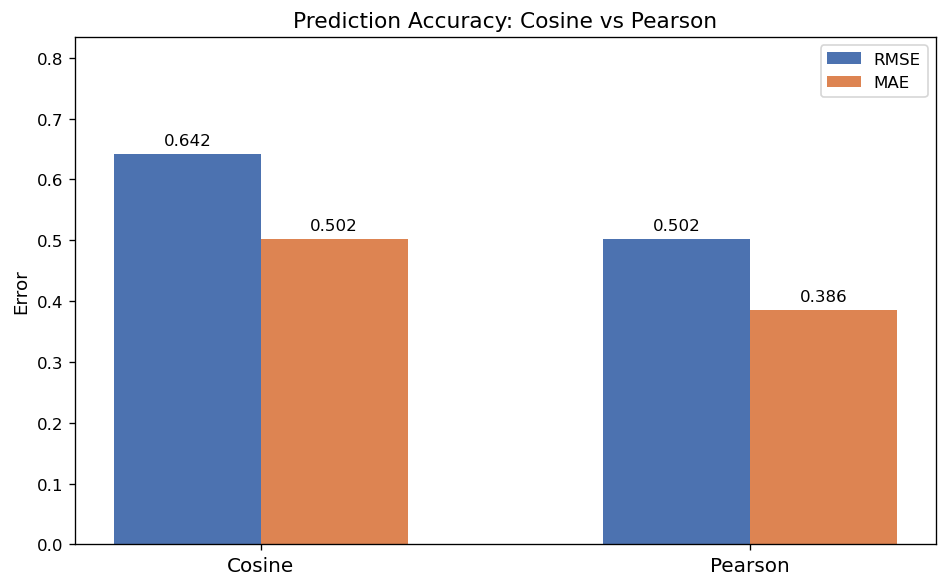

In [59]:
# Bar chart comparison
metrics = {
    "Cosine":  (rmse_cos,  mae_cos),
    "Pearson": (rmse_pea, mae_pea),
}

labels = list(metrics.keys())
rmse_vals = [v[0] for v in metrics.values()]
mae_vals  = [v[1] for v in metrics.values()]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, rmse_vals, width, label="RMSE", color="#4C72B0")
bars2 = ax.bar(x + width/2, mae_vals,  width, label="MAE",  color="#DD8452")

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Error")
ax.set_title("Prediction Accuracy: Cosine vs Pearson", fontsize=13)
ax.legend()
ax.set_ylim(0, max(rmse_vals + mae_vals) * 1.3)
plt.tight_layout()
plt.savefig("evaluation.png", bbox_inches="tight")
plt.show()

#### Comparison of Prediction Accuracy

The results show that Pearson correlation achieved better prediction accuracy than cosine similarity on the sampled ratings.

- Cosine Similarity: RMSE = 0.642, MAE = 0.502
- Pearson Correlation: RMSE = 0.502, MAE = 0.386

Both evaluation metrics are lower for Pearson correlation, indicating that its predicted ratings were generally closer to the actual user ratings. This suggests that Pearson correlation was more effective at capturing user preference patterns in the MovieLens dataset.

The difference in performance is consistent with earlier observations. While cosine similarity tended to recommend broadly popular movies, Pearson correlation focused more on similarities in rating behaviour. As a result, Pearson correlation produced more accurate rating predictions for this dataset.

### Final Observation
An interesting finding is that Pearson correlation not only produced different recommendations from cosine similarity, but also achieved lower RMSE and MAE values. This indicates that Pearson correlation was better able to model user preferences and predict unseen ratings in the MovieLens dataset. Therefore, among the two similarity measures tested, Pearson correlation provided the most accurate item-based collaborative filtering recommender.